# **잔차 연결 MLP**

- Radius : 전체 이미지의 정가운데 좌표와 바운딩 박스의 중심 좌표 간의 거리
- Theta : Radius와 x축 간의 각도

# **데이터 로드 및 증강**

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 모델 분석 및 시각화 도구
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn (데이터 전처리 및 모델 평가)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# 모델 설계
import tensorflow as tf

# 모델 구조 및 레이어
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D, Add, Activation,
Flatten, Dropout, BatchNormalization,
LeakyReLU, GlobalAveragePooling2D, concatenate)

# 사전 훈련된 모델
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2, MobileNetV3Small, VGG16, InceptionV3, Xception, DenseNet121

# 컴파일 및 훈련 관련
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [3]:
# 이미지 파일과 CSV 파일 로드 함수
def load_original_data(csv_path, image_root, image_size):
    df = pd.read_csv(csv_path)

    images, coords, labels = [], [], []
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        img_path = os.path.join(image_root, row['class'], row['cropped_image'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"경고: 이미지를 로드할 수 없습니다 - {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)

        coord_data = [row['x_center_norm'], row['y_center_norm'], row['width_norm'], row['height_norm'], row['radius'], row['theta']]

        images.append(img)
        coords.append(coord_data)
        labels.append(row['class'])

    print(f"-> 원본 데이터 로딩 완료: {len(images)}개 샘플")
    return np.array(images), np.array(coords), np.array(labels)

# 클래스 별 데이터의 개수를 맞추는 데이터 증강 함수
def balance_data_with_augmentation(original_images, original_coords, original_labels):

    # 데이터 증강 객체 정의
    datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.1, horizontal_flip=True, vertical_flip=True, fill_mode='nearest'
    )

    # 클래스별 데이터 수 확인 및 목표 개수 설정
    class_counts = pd.Series(original_labels).value_counts()
    target_count = class_counts.max()
    print(f"-> 데이터 증강 목표 개수 (각 클래스별): {target_count}")

    # 증강된 데이터만을 담을 리스트 초기화
    augmented_images, augmented_coords, augmented_labels = [], [], []

    # 소수 클래스에 대해서만 데이터 증강 수행
    for class_name, current_count in class_counts.items():
        if current_count < target_count:
            num_to_augment = target_count - current_count
            print(f"-> '{class_name}' 클래스 증강: +{num_to_augment}개")

            class_indices = np.where(original_labels == class_name)[0]
            images_to_augment = original_images[class_indices]
            coords_to_augment = original_coords[class_indices]

            for _ in range(num_to_augment):
                idx_to_pick = np.random.randint(0, len(images_to_augment))
                image = images_to_augment[idx_to_pick]
                coord = coords_to_augment[idx_to_pick]

                image = image.reshape((1, *image.shape))
                augmented_image_batch = next(datagen.flow(image, batch_size=1))
                augmented_image = augmented_image_batch[0].astype('uint8')

                augmented_images.append(augmented_image)
                augmented_coords.append(coord)
                augmented_labels.append(class_name)

    # 원본 데이터와 증강된 데이터를 결합
    balanced_images = np.concatenate([original_images, np.array(augmented_images)], axis=0)
    balanced_coords = np.concatenate([original_coords, np.array(augmented_coords)], axis=0)
    balanced_labels = np.concatenate([original_labels, np.array(augmented_labels)], axis=0)

    # 최종 데이터셋 섞기
    return shuffle(balanced_images, balanced_coords, balanced_labels, random_state=42)

In [4]:
dataset_path = "/content/drive/MyDrive/ACK2025_Wafer/YOLO/Defect_Pattern_CNN_Dataset"
zip_file_name = "Pattern_Image_Coordinated_Dataset_v3.zip"
unzipped_dataset_path = "Pattern_Image_Coordinated_Dataset_v3"

# Colab 로컬로 데이터셋 이동 및 복사
print("데이터셋을 Colab 로컬 환경으로 복사합니다...")

# 변수를 사용하여 파일 경로를 동적으로 생성
zip_file_path_in_drive = os.path.join(dataset_path, zip_file_name)
!cp "{zip_file_path_in_drive}" /content/
print("압축 해제를 시작합니다...")
!unzip -o -q /content/"{zip_file_name}" -d /content/
print("데이터셋 준비 완료.")

# 로컬 폴더 목록 확인
print("\n/content/ 폴더 내용 확인:")
!ls -l /content/

데이터셋을 Colab 로컬 환경으로 복사합니다...
압축 해제를 시작합니다...
데이터셋 준비 완료.

/content/ 폴더 내용 확인:
total 156412
drwx------  6 root root      4096 Aug  7 08:58 drive
drwxrwxrwx 10 root root      4096 Aug  6 09:41 Pattern_Image_Coordinated_Dataset_v3
-rw-------  1 root root 160149814 Aug  7 08:59 Pattern_Image_Coordinated_Dataset_v3.zip
drwxr-xr-x  1 root root      4096 Aug  5 17:22 sample_data


In [5]:
# 데이터셋 경로 설정 및 이미지 크기 조절
csv_path = os.path.join(dataset_path, "bbox_info_v2.csv")
image_path = os.path.join("/content/", unzipped_dataset_path)
image_size = (128, 128)


# 원본 데이터 로드 ( X: 입력 데이터, y: 라벨 데이터 )
X_original_images, X_original_coords, y_original_labels = load_original_data(csv_path, image_path, image_size)

# 데이터 증강
X_images, X_coords, y_labels_str = balance_data_with_augmentation(X_original_images, X_original_coords, y_original_labels)

# 데이터 정규화
X_images = X_images.astype('float32') / 255.0
X_coords = X_coords.astype('float32')

# 원 핫 인코딩
encoder = LabelEncoder()
y_labels_encoded = encoder.fit_transform(y_labels_str)  # 클래스의 타입 변환(정수)
classes_num = len(encoder.classes_)
y_labels_categorical = to_categorical(y_labels_encoded, num_classes=classes_num)  # 정수 -> 벡터

# 데이터셋 정보 출력
print(f"\n총 샘플 개수: {len(X_images)}")
print(f"클래스 종류 ({classes_num}개): {encoder.classes_}")
print("\n최종 클래스별 데이터 분포:")
print(pd.Series(y_labels_str).value_counts())



 25%|██▌       | 1668/6570 [00:02<00:08, 589.07it/s]

경고: 이미지를 로드할 수 없습니다 - /content/Pattern_Image_Coordinated_Dataset_v3/Edge-Loc/Donut99_obj0.png


100%|██████████| 6570/6570 [00:16<00:00, 405.64it/s] 


-> 원본 데이터 로딩 완료: 6569개 샘플
-> 데이터 증강 목표 개수 (각 클래스별): 1000
-> 'Edge-Loc' 클래스 증강: +1개
-> 'Random' 클래스 증강: +134개
-> 'Donut' 클래스 증강: +445개
-> 'Near-full' 클래스 증강: +851개

총 샘플 개수: 8000
클래스 종류 (8개): ['Center' 'Donut' 'Edge-Loc' 'Edge-Ring' 'Loc' 'Near-full' 'Random'
 'Scratch']

최종 클래스별 데이터 분포:
Edge-Loc     1000
Edge-Ring    1000
Loc          1000
Donut        1000
Near-full    1000
Random       1000
Scratch      1000
Center       1000
Name: count, dtype: int64


In [6]:
# 증강 확인
print(f"X 이미지 shape: {X_images.shape}")
print(f"좌표 shape: {X_coords.shape}")
print(f"라벨 (one-hot) shape: {y_labels_categorical.shape}")

X 이미지 shape: (8000, 128, 128, 3)
좌표 shape: (8000, 6)
라벨 (one-hot) shape: (8000, 8)


In [7]:
# 학습용, 테스트용 데이터 분리
X_img_train, X_img_test, X_coords_train, X_coords_test, y_train_encoded, y_test_encoded = train_test_split(
  X_images,
  X_coords,
  y_labels_encoded,
  test_size=0.2,
  random_state=42,
  stratify=y_labels_encoded
)

y_train = to_categorical(y_train_encoded, num_classes=classes_num)
y_test = to_categorical(y_test_encoded, num_classes=classes_num)

# 학습 및 훈련 데이터셋의 데이터 개수 확인
print("\n 학습 데이터셋의 클래스 분포")
y_train_labels = np.argmax(y_train, axis=1) # 원-핫 인코딩 -> 정수 라벨로 변환
print(pd.Series(y_train_labels).map(lambda x: encoder.classes_[x]).value_counts())
print("\n 테스트 데이터셋의 클래스 분포")
y_test_labels = np.argmax(y_test, axis=1) # 원-핫 인코딩 -> 정수 라벨로 변환
print(pd.Series(y_test_labels).map(lambda x: encoder.classes_[x]).value_counts())


 학습 데이터셋의 클래스 분포
Near-full    800
Donut        800
Center       800
Scratch      800
Random       800
Edge-Ring    800
Edge-Loc     800
Loc          800
Name: count, dtype: int64

 테스트 데이터셋의 클래스 분포
Scratch      200
Near-full    200
Edge-Loc     200
Center       200
Edge-Ring    200
Random       200
Loc          200
Donut        200
Name: count, dtype: int64


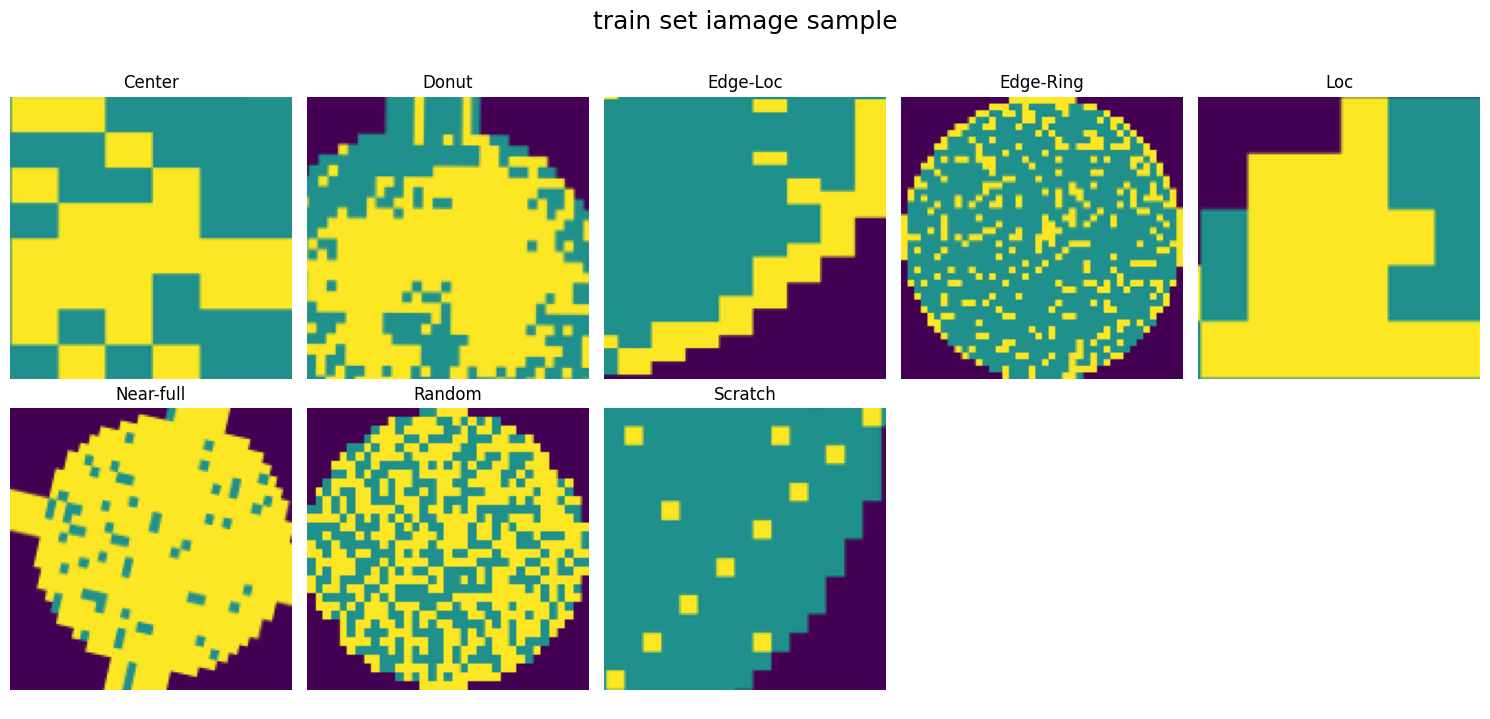

In [8]:
unique_classes = encoder.classes_
num_classes = len(unique_classes)

# 출력될 이미지 크기 설정
cols = 5
rows = math.ceil(num_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten()

# 각 클래스 별 이미지 출력
for i, class_name in enumerate(unique_classes):
  class_code = encoder.transform([class_name])[0]

  # 해당 클래스의 인덱스들 가져오기
  class_indices = np.where(y_train_labels == class_code)[0]

  # 랜덤 선택
  idx_in_train_set = np.random.choice(class_indices)

  # 훈련 데이터셋에서 이미지 로드
  sample_image = X_img_train[idx_in_train_set]

  # 격자를 통해 이미지 출력
  ax = axes[i]
  ax.imshow(sample_image)
  ax.set_title(class_name, fontsize=12)
  ax.axis('off')

# 격자의 빈 공간 제거
for j in range(i + 1, len(axes)):
  axes[j].axis('off')

plt.suptitle('train set iamage sample', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# **모델 학습**

In [9]:
# 모델 학습 결과 시각화 함수
def plot_training_history(history, model_name):

  # 정확도 그래프
  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{model_name} - Accuracy', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Accuracy', fontsize=12)
  plt.legend()
  plt.grid(True)

  # 손실 그래프
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{model_name} - Loss', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# 혼동 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred_probs, class_names, normalize=False, title='Confusion Matrix'):

  # 확률을 최종 클래스 예측(인덱스)으로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)
  y_true_classes = np.argmax(y_true, axis=1)

  # normalize 옵션 설정
  if normalize:
    # 'true': 실제 라벨(행)을 기준으로 정규화
    cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
    fmt = '.2f' # 소수점 둘째 자리까지 표시
  else:
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    fmt = 'd' # 정수로 표시

  # 혼동 행렬 시각화
  plt.figure(figsize=(9, 8))
  sns.heatmap(
    cm,
    annot=True,
    fmt=fmt, # [개선 2] 포맷 변경
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
  )

  plt.xlabel('Predicted Class', fontsize=12)
  plt.ylabel('Actual Class', fontsize=12)
  plt.title(title, fontsize=15)
  plt.show()


## **1. Multi-Input DNN with Residual Connection**

In [10]:
# --- 모델 구성 ---

# 입력층 설정
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(6,), name='coords_input')

# 이미지 처리 브랜치
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)
image_features = Dense(64, activation='relu')(image_features)

# 좌표 처리 브랜치
rc = Dense(32, activation='relu')(coords_input)
rc = Dense(32, activation='relu')(rc)

shortcut = Dense(32)(coords_input)

added = Add()([rc, shortcut])
coords_features = Activation('relu')(rc)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
x1 = Dense(64, activation='relu')(combined)
output = Dense(classes_num, activation='softmax')(x1)

# 최종 모델 생성
model_multi_input_dnn = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_dnn.summary()

# --- 모델 컴파일 ---
model_multi_input_dnn.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)
# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 훈련 실행
history_dnn = model_multi_input_dnn.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=50,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coords_input        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 49152)     │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        224 │ coords_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  6,291,584 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32)        │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │        520 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,307,848 (24.06 MB)

 Trainable params: 6,307,848 (24.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5158 - loss: 1.8921 - val_accuracy: 0.7262 - val_loss: 0.7244
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8004 - loss: 0.5547 - val_accuracy: 0.8712 - val_loss: 0.3919
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8726 - loss: 0.3888 - val_accuracy: 0.8744 - val_loss: 0.3945
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9011 - loss: 0.3073 - val_accuracy: 0.8875 - val_loss: 0.3662
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9069 - loss: 0.2883 - val_accuracy: 0.8888 - val_loss: 0.3611
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9005 - loss: 0.2820 - val_accuracy: 0.8737 - val_loss: 0.4083
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9180 - loss: 0.2632 - val_accuracy: 0.8963 - val_loss: 0.3552
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9169 - loss: 0.2511 - val_accuracy: 0

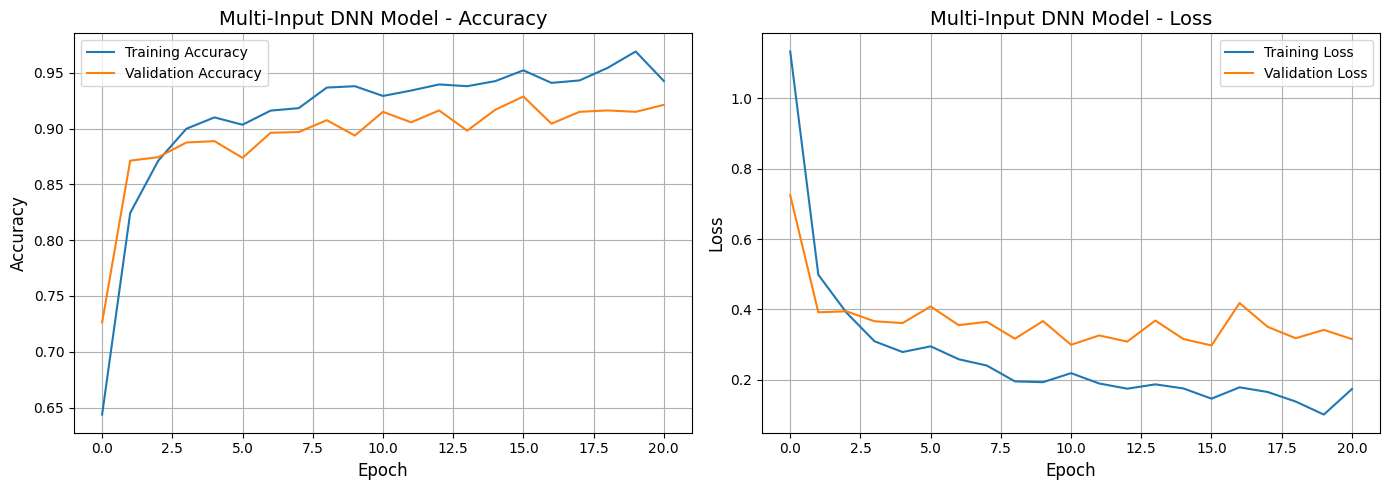

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


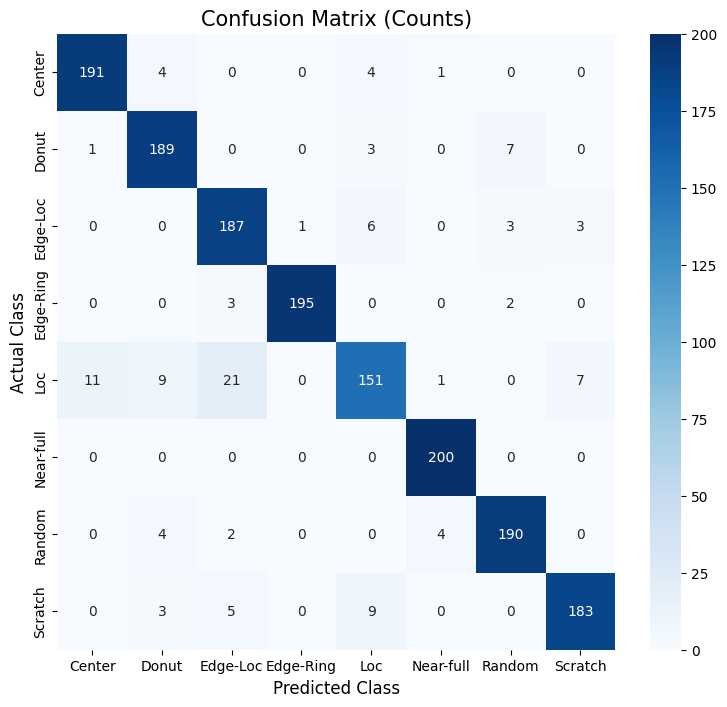

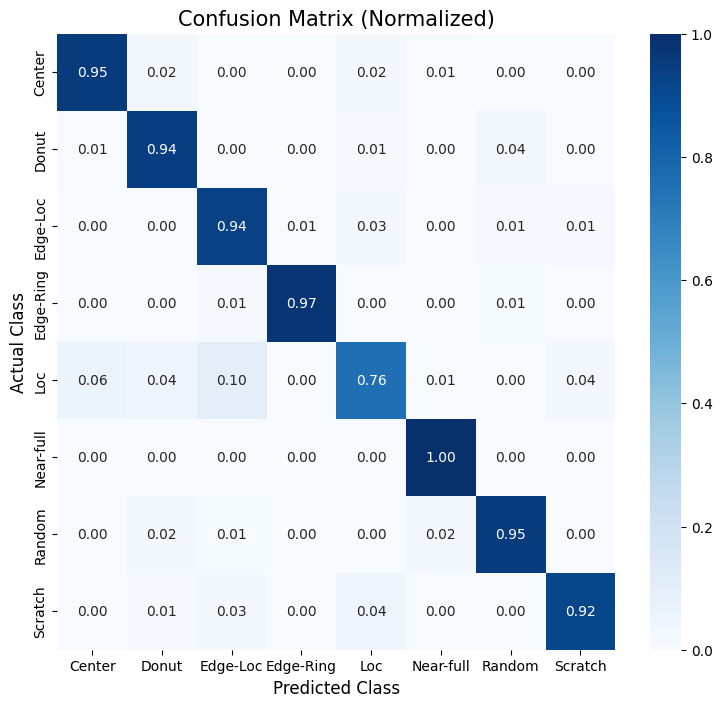

In [11]:
# 훈련 모델 성능 시각화
plot_training_history(history_dnn, "Multi-Input DNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_dnn.predict([X_img_test, X_coords_test])

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **2. Multi-Input MobileNetV2 with Residual Connection**

In [12]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(6,), name='coords_input')

# 이미지 처리 브랜치 (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 MobileNetV2의 가중치 동결
base_model.trainable = False

# MobileNetV2의 출력에 커스텀 레이어 추가
x2 = base_model.output
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(128, activation='relu')(x2)
image_features = Dropout(0.5)(x2)

# 좌표 처리 브랜치 (MLP)
rc = Dense(32, activation='relu')(coords_input)
rc = Dense(32, activation='relu')(rc)

# 지름길
shortcut = Dense(32)(coords_input)

# 결합 및 활성화
added = Add()([rc, shortcut])
coords_features = Activation('relu')(added)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z2 = Dense(64, activation='relu')(combined)
z2 = Dropout(0.5)(z2)
output = Dense(num_classes, activation='softmax')(z2) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_mobilenetv2 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_mobilenetv2.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_mobilenetv2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_mobilenetv2 = model_multi_input_mobilenetv2.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

/tmp/ipython-input-1756895786.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,434,280 (9.29 MB)

 Trainable params: 176,296 (688.66 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.2398 - loss: 2.2867 - val_accuracy: 0.6488 - val_loss: 1.1293
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4850 - loss: 1.4047 - val_accuracy: 0.6831 - val_loss: 0.9488
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5640 - loss: 1.1862 - val_accuracy: 0.6931 - val_loss: 0.8717
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5935 - loss: 1.1022 - val_accuracy: 0.7125 - val_loss: 0.8077
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5992 - loss: 1.0529 - val_accuracy: 0.7125 - val_loss: 0.7854
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6167 - loss: 0.9956 - val_accuracy: 0.7212 - val_loss: 0.7624
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6444 - loss: 0.9581 - val_accuracy: 0.7300 - val_loss: 0.7341
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6658 - loss: 0.9089 -

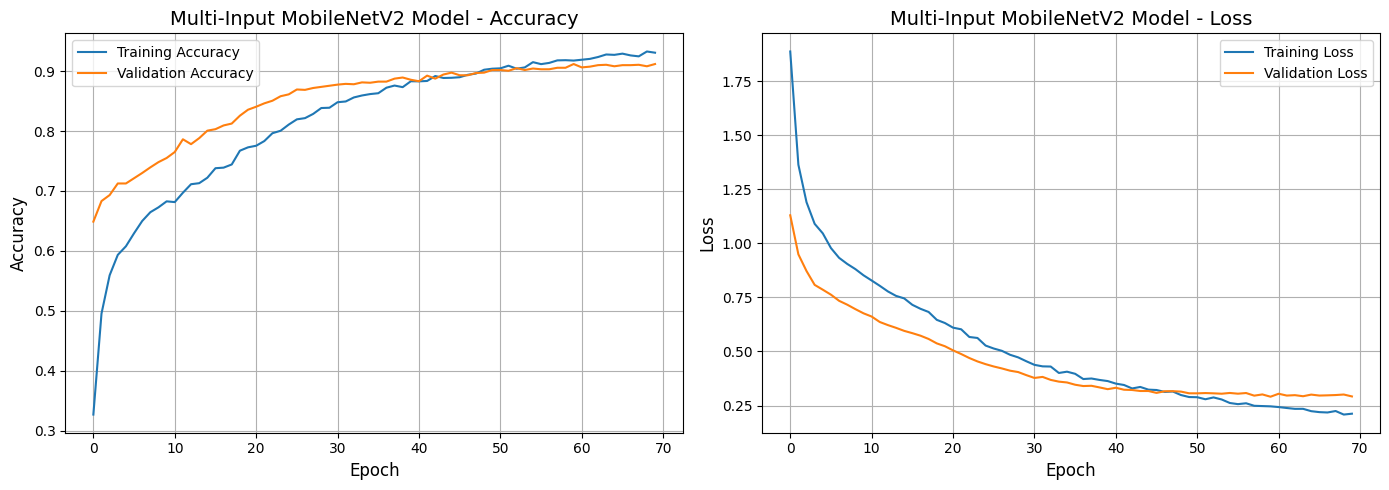

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


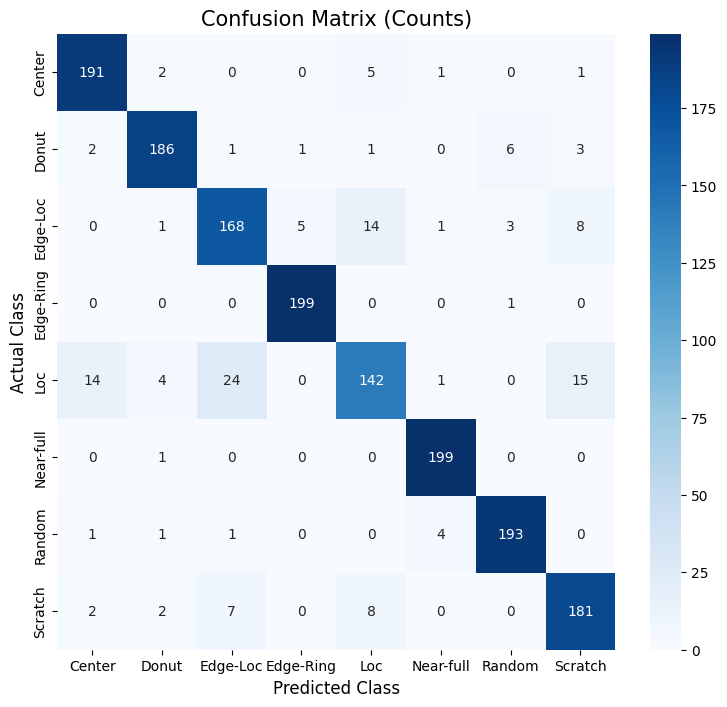

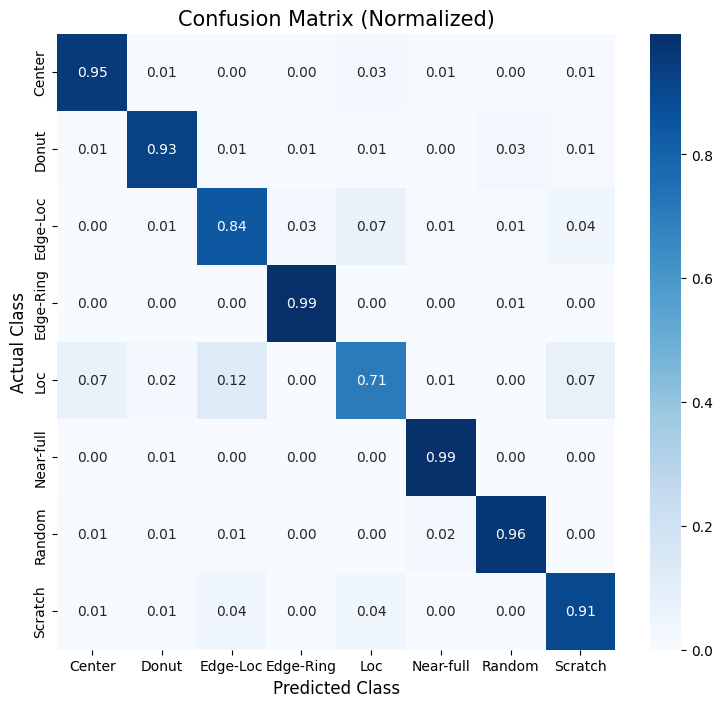

In [13]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv2, "Multi-Input MobileNetV2 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_mobilenetv2.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **3. Multi-Input VGG16 with Residual Connection**

In [14]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(6,), name='coords_input')

# 이미지 처리 브랜치 (VGG16)
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 VGG16의 가중치 동결
base_model.trainable = False

# VGG16의 출력에 커스텀 레이어 추가
x8 = base_model.output
x8 = GlobalAveragePooling2D()(x8)
x8 = Dense(128, activation='relu')(x8)
image_features = Dropout(0.5)(x8)

# 좌표 처리 브랜치 (MLP)
rc = Dense(32, activation='relu')(coords_input)
rc = Dense(32, activation='relu')(rc)

# 지름길
shortcut = Dense(32)(coords_input)

# 결합 및 활성화
added = Add()([rc, shortcut])
coords_features = Activation('relu')(added)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z8 = Dense(64, activation='relu')(combined)
z8 = Dropout(0.5)(z8)
output = Dense(num_classes, activation='softmax')(z8) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_vgg16 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_vgg16.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_vgg16.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_vgg16 = model_multi_input_vgg16.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ image_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 14,792,680 (56.43 MB)

 Trainable params: 77,992 (304.66 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.1614 - loss: 2.3135 - val_accuracy: 0.5456 - val_loss: 1.7360
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.2864 - loss: 1.8228 - val_accuracy: 0.6225 - val_loss: 1.4249
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.4063 - loss: 1.5675 - val_accuracy: 0.6781 - val_loss: 1.2079
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.4755 - loss: 1.3959 - val_accuracy: 0.6925 - val_loss: 1.0637
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.5290 - loss: 1.2715 - val_accuracy: 0.7237 - val_loss: 0.9732
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5576 - loss: 1.2023 - val_accuracy: 0.7437 - val_loss: 0.9080
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5928 - loss: 1.1287 - val_accuracy: 0.7469 - val_loss: 0.8438
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6099 - loss: 1

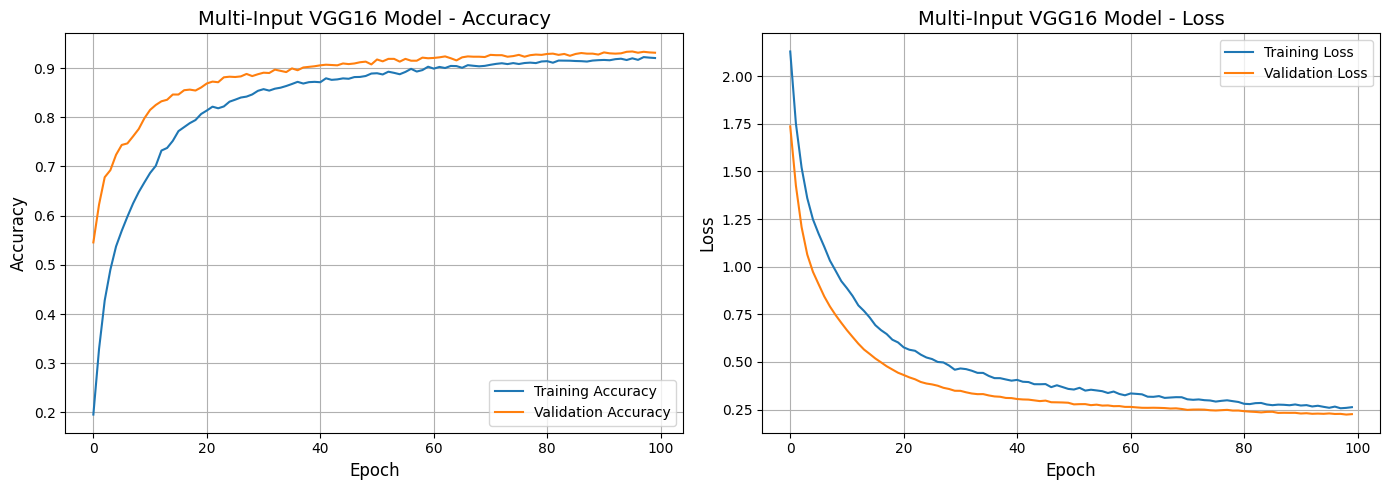

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step


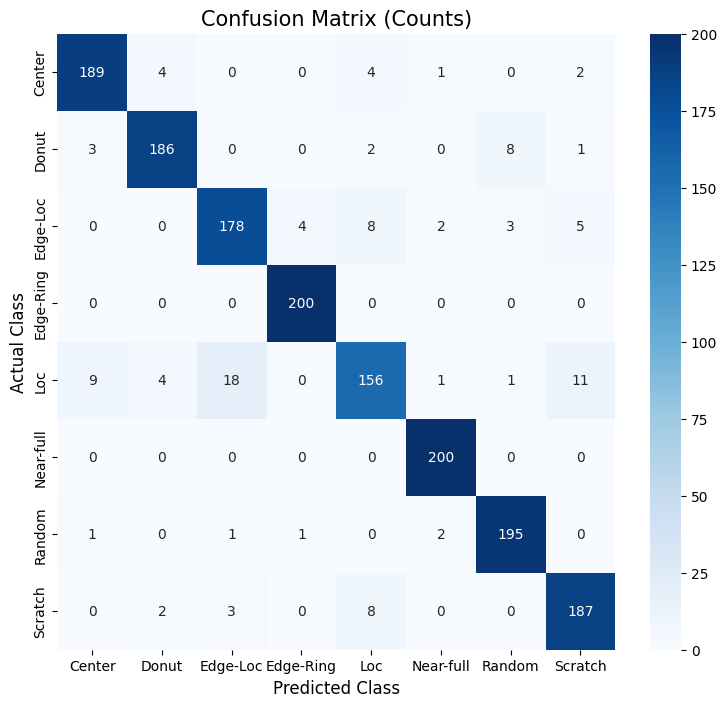

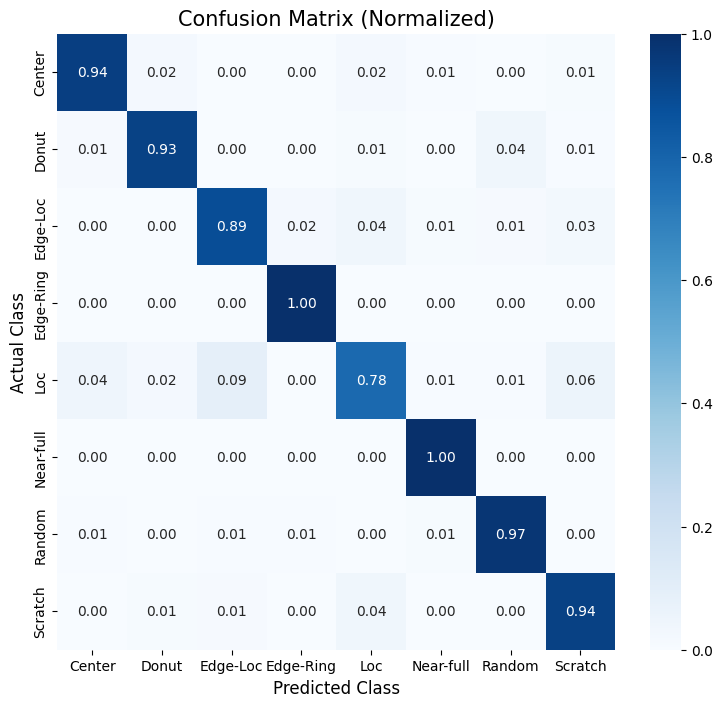

In [15]:
# 훈련 모델 성능 시각화
plot_training_history(history_vgg16, "Multi-Input VGG16 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_vgg16.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **4. Multi-Input DenseNet121 with Residual Connection**

In [16]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(6,), name='coords_input')

# 이미지 처리 브랜치 (DenseNet121)
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 DenseNet121의 가중치 동결
base_model.trainable = False

# DenseNet121의 출력에 커스텀 레이어 추가
x11 = base_model.output
x11 = GlobalAveragePooling2D()(x11)
x11 = Dense(128, activation='relu')(x11)
image_features = Dropout(0.5)(x11)

# 좌표 처리 브랜치 (MLP)
rc = Dense(32, activation='relu')(coords_input)
rc = Dense(32, activation='relu')(rc)

# 지름길
shortcut = Dense(32)(coords_input)

# 결합 및 활성화
added = Add()([rc, shortcut])
coords_features = Activation('relu')(added)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z11 = Dense(64, activation='relu')(combined)
z11 = Dropout(0.5)(z11)
output = Dense(num_classes, activation='softmax')(z11) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_densenet121 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_densenet121.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_densenet121.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_densenet121 = model_multi_input_densenet121.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,181,032 (27.39 MB)

 Trainable params: 143,528 (560.66 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.1800 - loss: 2.4575 - val_accuracy: 0.6231 - val_loss: 1.3547
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4604 - loss: 1.5078 - val_accuracy: 0.6400 - val_loss: 1.1071
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.5171 - loss: 1.3101 - val_accuracy: 0.6800 - val_loss: 0.9955
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.5623 - loss: 1.1834 - val_accuracy: 0.6963 - val_loss: 0.9192
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.5995 - loss: 1.1015 - val_accuracy: 0.7262 - val_loss: 0.8482
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6231 - loss: 1.0432 - val_accuracy: 0.7538 - val_loss: 0.7993
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6455 - loss: 0.9819 - val_accuracy: 0.7706 - val_loss: 0.7542
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6654 - loss: 0.9399 

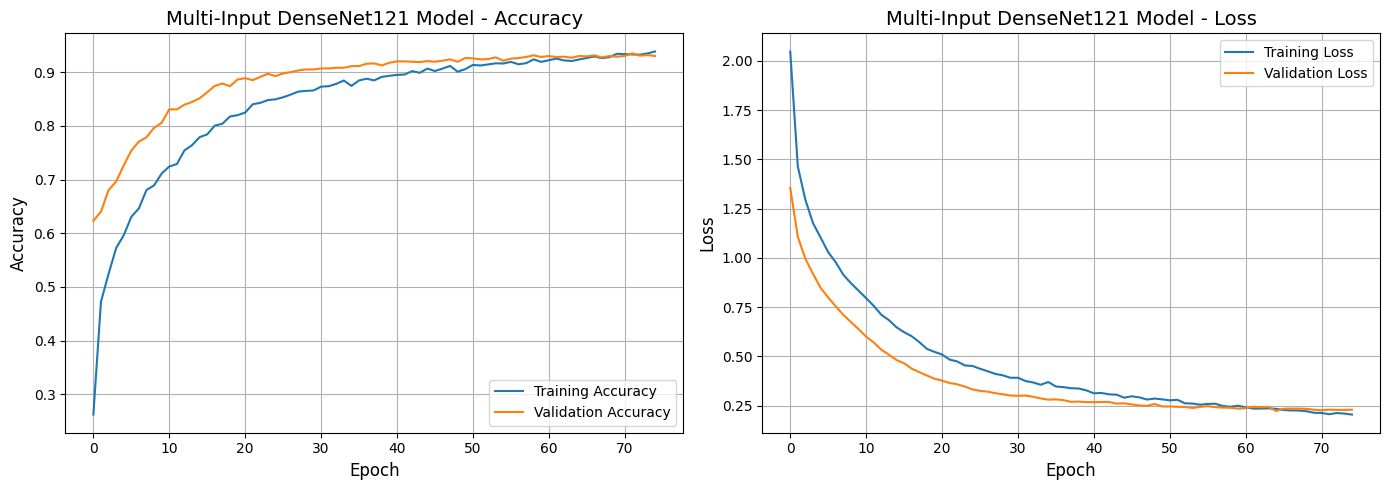

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step


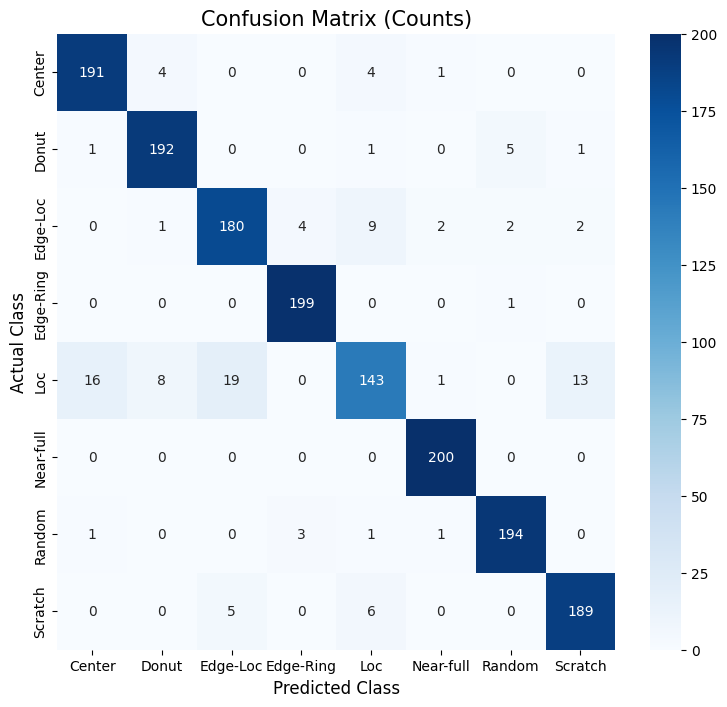

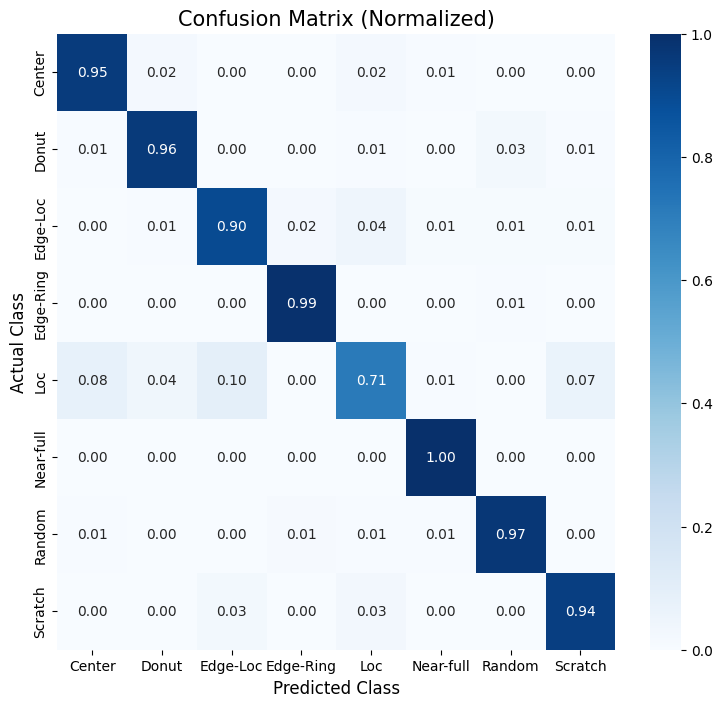

In [17]:
# 훈련 모델 성능 시각화
plot_training_history(history_densenet121, "Multi-Input DenseNet121 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_densenet121.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

# **성능 비교 결과**

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 평가할 모델들을 딕셔너리로 정의
models_to_evaluate = {
    "Multi-Input DNN": model_multi_input_dnn,
    "Multi-Input MobileNetV2": model_multi_input_mobilenetv2,
    "Multi-Input VGG16": model_multi_input_vgg16,
    "Multi-Input DenseNet121": model_multi_input_densenet121
}

results = []

y_test_classes = np.argmax(y_test, axis=1)

# 모델 별 성능 평가
for model_name, model in models_to_evaluate.items():

  # 예측 수행
  y_pred_probs = model.predict([X_img_test, X_coords_test], verbose=0)

  # 예측된 확률을 최종 클래스로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)

  # 평가 지표 계산
  accuracy = accuracy_score(y_test_classes, y_pred_classes)
  precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
  recall = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
  f1 = f1_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)

  # 결과 저장
  results.append({
      "Model": model_name,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "F1-Score": f1
  })

# 최종 결과 출력
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n\n--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---")
display(results_df_sorted)



--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Multi-Input VGG16,0.931875,0.930913,0.931875,0.930922
1,Multi-Input DenseNet121,0.930000,0.928593,0.930000,0.928174
2,Multi-Input DNN,0.928750,0.928797,0.928750,0.927891
3,Multi-Input MobileNetV2,0.911875,0.910310,0.911875,0.910286
